# Python Exercise #1 — Amazon (AMZN)

Completed price and return analysis, adapted from the supplied course notebook.

**Data:** Yahoo Finance via yfinance; daily adjusted closing prices. The original notebook's date settings are retained: January 1, 2024 to December 31, 2025 (end exclusive). The download contains 501 prices, yielding 500 daily returns from January 3, 2024 through December 30, 2025. All code cells below have been executed. Returns in figures and summaries are expressed in percent unless otherwise labeled.

**Figure guide:** Figure 1 compares price and simple-return histograms; Figure 2 shows the three time series; Figure 3 contains the simple-return histogram and Q–Q plot; Figure 4 contains the corresponding log-return diagnostics. The summary table's `Kurtosis` column reports **excess kurtosis**, whose Normal-distribution benchmark is zero.


# Amazon (AMZN): Price & Return Time Series Analysis

This notebook downloads daily AMZN prices, computes **simple** and **log** returns, and explores time-series behavior and return distributions.

**Key learning goals**
- Distinguish **prices** vs. **returns** for modeling
- Compare **simple** vs. **log** returns
- Interpret **distribution diagnostics** (histogram, Normal overlay, Q–Q plot, Jarque–Bera)


In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

## 1. Setup
Import packages used throughout the notebook.


## 2. Download price data
We pull daily AMZN data and keep the adjusted close as our price series.


In [2]:
TICKER = "AMZN"  # Change this to your chosen publicly traded stock.
START_DATE = "2024-01-01"
END_DATE = "2025-12-31"  # Exclusive end date, matching the supplied notebook.

# Download daily data (AMZN) and keep adjusted close
df = yf.download(
    TICKER,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=False,
    progress=False
)

if df.empty:
    raise ValueError("No price data downloaded. Check ticker and internet connection.")
# Keep adjusted close only
df = df.loc[:, ["Adj Close"]]

# yfinance often returns a MultiIndex (field, ticker). Flatten for a single-asset notebook.
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df = df.rename(columns={"Adj Close": "adj_close"})
df.index.name = "Date"

df


Price,adj_close
Date,
2024-01-02,149.929993
2024-01-03,148.470001
2024-01-04,144.570007
2024-01-05,145.240005
2024-01-08,149.100006
...,...
2025-12-23,232.139999
2025-12-24,232.380005
2025-12-26,232.520004


## 3. Inspect the raw data


In [3]:
print(f'Downloaded {df.shape[0]} rows of data')
df.head()

Downloaded 501 rows of data


Price,adj_close
Date,
2024-01-02,149.929993
2024-01-03,148.470001
2024-01-04,144.570007
2024-01-05,145.240005
2024-01-08,149.100006


## 4. Compute returns
- **Simple return**: $r_t = P_t/P_{t-1}-1$
- **Log return**: $\ln(P_t/P_{t-1})$


In [4]:
# Compute returns (in decimal form; e.g., 0.01 = 1%)
df["simple_rtn"] = df["adj_close"].pct_change()
df["log_rtn"] = np.log(df["adj_close"] / df["adj_close"].shift(1))

df.head()


Price,adj_close,simple_rtn,log_rtn
Date,,,
2024-01-02,149.929993,NaN,NaN
2024-01-03,148.470001,-0.009738,-0.009786
2024-01-04,144.570007,-0.026268,-0.026619
2024-01-05,145.240005,0.004634,0.004624
2024-01-08,149.100006,0.026577,0.026230


## 5. Clean the dataset
We drop the first row (returns are undefined on the first day).


In [5]:
df = df.dropna(how="any").copy()
df.head()


Price,adj_close,simple_rtn,log_rtn
Date,,,
2024-01-03,148.470001,-0.009738,-0.009786
2024-01-04,144.570007,-0.026268,-0.026619
2024-01-05,145.240005,0.004634,0.004624
2024-01-08,149.100006,0.026577,0.026230
2024-01-09,151.369995,0.015225,0.015110


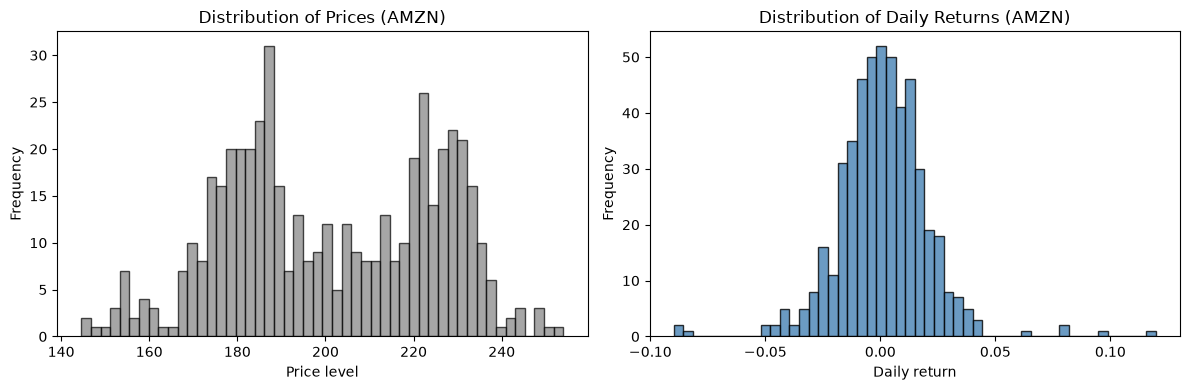

In [6]:
# =========================
# Histogram comparison: price vs. returns (with color contrast)
# =========================

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Price histogram (neutral / muted)
ax[0].hist(
    df["adj_close"],
    bins=50,
    color="gray",
    alpha=0.7,
    edgecolor="black"
)
ax[0].set_title(f"Distribution of Prices ({TICKER})")
ax[0].set_xlabel("Price level")
ax[0].set_ylabel("Frequency")

# Return histogram (analytic focus)
ax[1].hist(
    df["simple_rtn"].dropna(),
    bins=50,
    color="steelblue",
    alpha=0.8,
    edgecolor="black"
)
ax[1].set_title(f"Distribution of Daily Returns ({TICKER})")
ax[1].set_xlabel("Daily return")
ax[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


## 6. Time-series plots: price vs. returns
Returns are plotted in **percent** for readability.


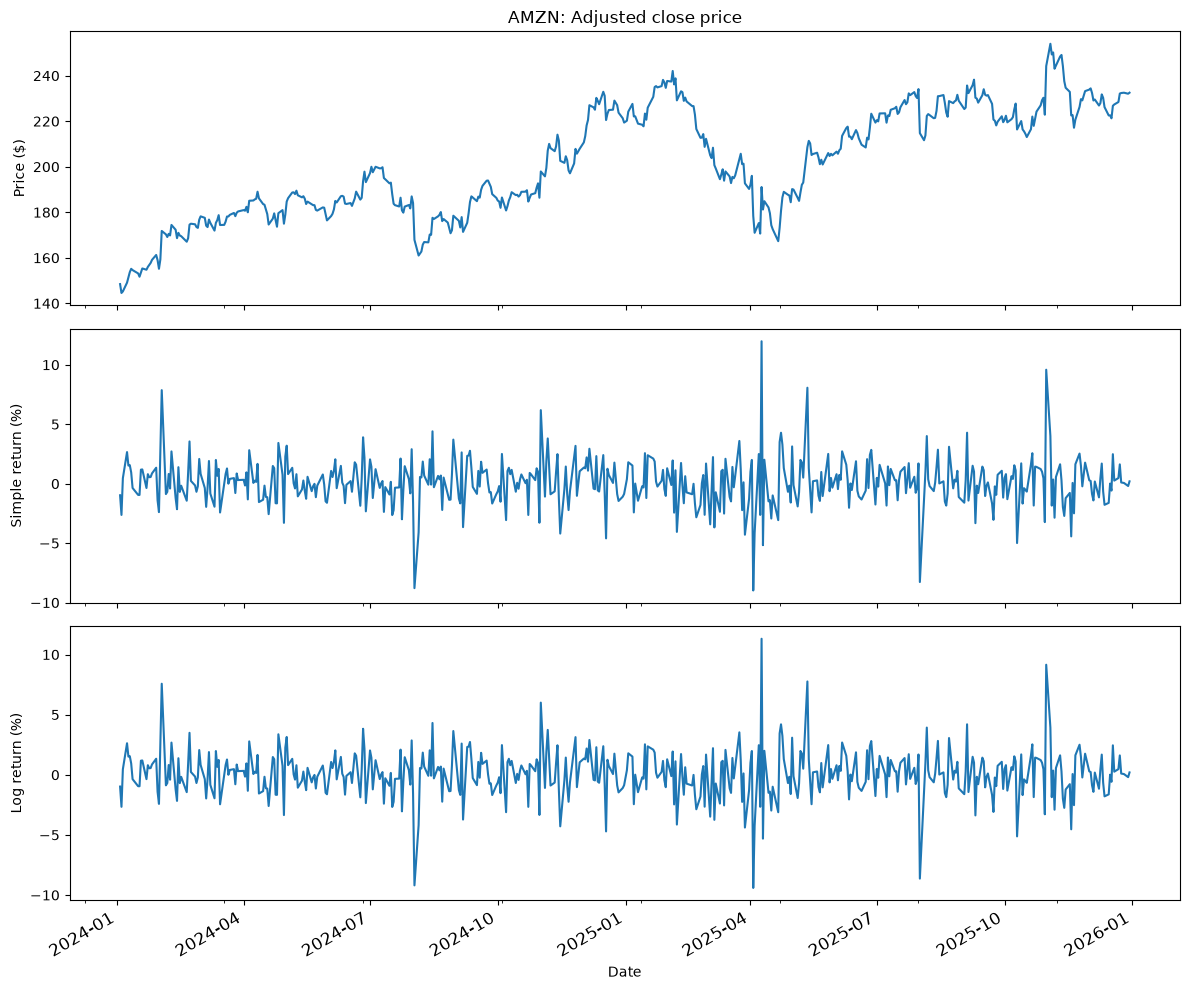

In [7]:
fig, ax = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Price
df["adj_close"].plot(ax=ax[0])
ax[0].set(
    title=f"{TICKER}: Adjusted close price",
    ylabel="Price ($)"
)

# Simple returns (percent)
(df["simple_rtn"] * 100).plot(ax=ax[1])
ax[1].set(ylabel="Simple return (%)")

# Log returns (percent)
(df["log_rtn"] * 100).plot(ax=ax[2])
ax[2].set(
    xlabel="Date",
    ylabel="Log return (%)"
)

ax[2].tick_params(axis="x", which="major", labelsize=12)
plt.tight_layout()
plt.show()


## 7. Return distribution diagnostics
We examine histograms with a Normal overlay, Q–Q plots, and normality tests.


In [8]:
# =========================
# Descriptive statistics: price and returns
# (Returns shown in percent for readability)
# =========================

price = df["adj_close"]
simple_rtn_pct = df["simple_rtn"] * 100
log_rtn_pct = df["log_rtn"] * 100

stats = pd.DataFrame({
    "Price ($)": price,
    "Simple Return (%)": simple_rtn_pct,
    "Log Return (%)": log_rtn_pct
}).describe().T

stats["Skewness"] = [price.skew(), simple_rtn_pct.skew(), log_rtn_pct.skew()]
stats["Kurtosis"] = [price.kurtosis(), simple_rtn_pct.kurtosis(), log_rtn_pct.kurtosis()]

stats.round(4)


,count,mean,std,min,25%,50%,75%,max,Skewness,Kurtosis
Price ($),500.0,201.1278,23.7953,144.5700,182.0950,199.2700,222.9425,254.0000,-0.0456,-1.0517
Simple Return (%),500.0,0.1073,1.9797,-8.9791,-0.9377,0.0708,1.2333,11.9770,0.2993,5.7888
Log Return (%),500.0,0.0878,1.9747,-9.4081,-0.9421,0.0708,1.2258,11.3124,0.0768,5.4897


*Note:* If you ever need to confirm the DataFrame structure, run `df.columns` in a code cell.


### 7.1 Packages for distribution diagnostics


In [9]:
import seaborn as sns 
import scipy.stats as scs
import statsmodels.api as sm
import statsmodels.tsa.api as smt

In [10]:
# Normal overlay parameters for SIMPLE returns (percent)
simple_rtn_pct = df["simple_rtn"] * 100

r_range = np.linspace(simple_rtn_pct.min(), simple_rtn_pct.max(), 1000)
mu = simple_rtn_pct.mean()
sigma = simple_rtn_pct.std()
norm_pdf = scs.norm.pdf(r_range, loc=mu, scale=sigma)


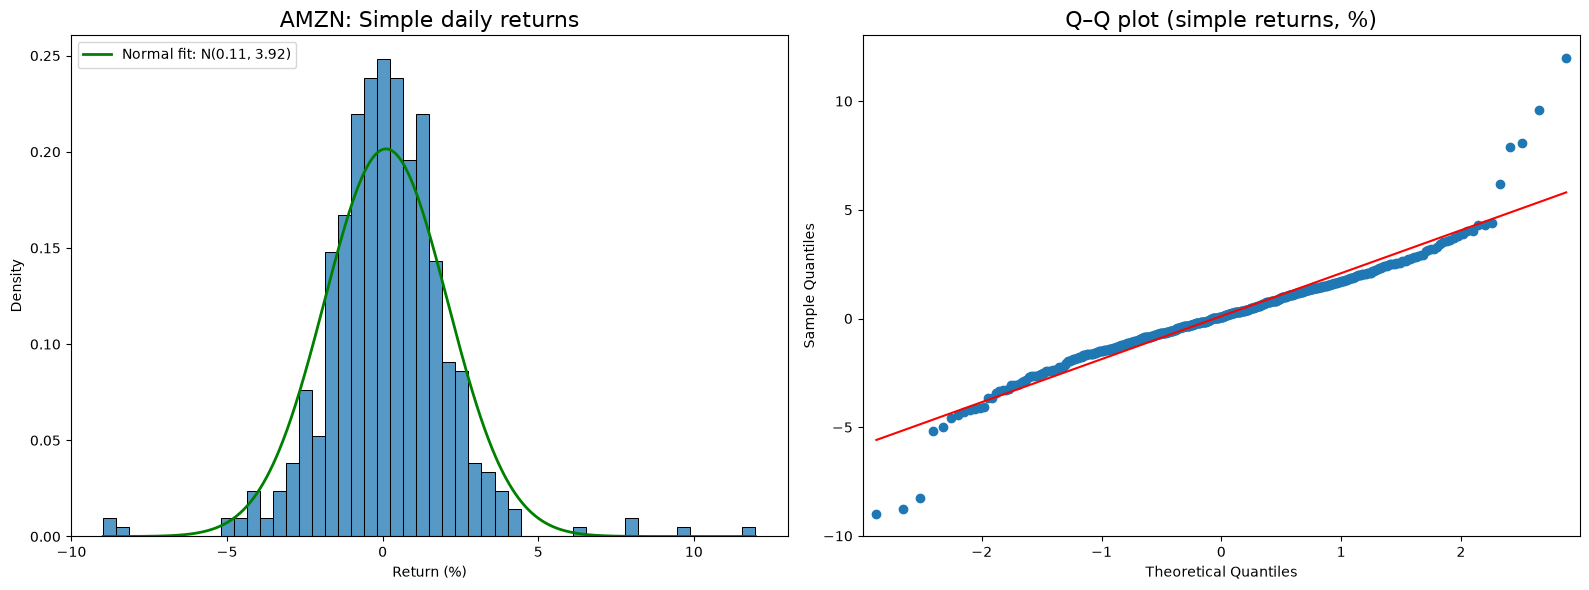

In [11]:
# Histogram + Q–Q plot: SIMPLE returns (percent)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Histogram (percent)
sns.histplot(simple_rtn_pct, bins=50, stat="density", ax=ax[0])
ax[0].set_title(f"{TICKER}: Simple daily returns", fontsize=16)
ax[0].set_xlabel("Return (%)")
ax[0].plot(r_range, norm_pdf, "g", lw=2, label=f"Normal fit: N({mu:.2f}, {sigma**2:.2f})")
ax[0].legend(loc="upper left")

# Q–Q plot (use the SAME series as the histogram)
sm.qqplot(simple_rtn_pct.values, line="s", ax=ax[1])
ax[1].set_title("Q–Q plot (simple returns, %)", fontsize=16)

plt.tight_layout()
plt.show()


In [12]:
# Summary statistics + normality test: SIMPLE returns

r = df["simple_rtn"].dropna()
r_pct = r * 100
jb_test = scs.jarque_bera(r.values)

print("---------- Simple Returns (Daily) ----------")
print("Range of dates:", r.index.min().date(), "-", r.index.max().date())
print("Number of observations:", r.shape[0])
print(f"Mean (%): {r_pct.mean():.4f}")
print(f"Median (%): {r_pct.median():.4f}")
print(f"Min (%): {r_pct.min():.4f}")
print(f"Max (%): {r_pct.max():.4f}")
print(f"Std Dev (%): {r_pct.std():.4f}")
print(f"Skewness: {r_pct.skew():.4f}")
print(f"Excess kurtosis: {r_pct.kurtosis():.4f}")
print(f"Jarque–Bera: {jb_test[0]:.2f}  |  p-value: {jb_test[1]:.3e}")


---------- Simple Returns (Daily) ----------
Range of dates: 2024-01-03 - 2025-12-30
Number of observations: 500
Mean (%): 0.1073
Median (%): 0.0708
Min (%): -8.9791
Max (%): 11.9770
Std Dev (%): 1.9797
Skewness: 0.2993
Excess kurtosis: 5.7888
Jarque–Bera: 688.85  |  p-value: 2.622e-150


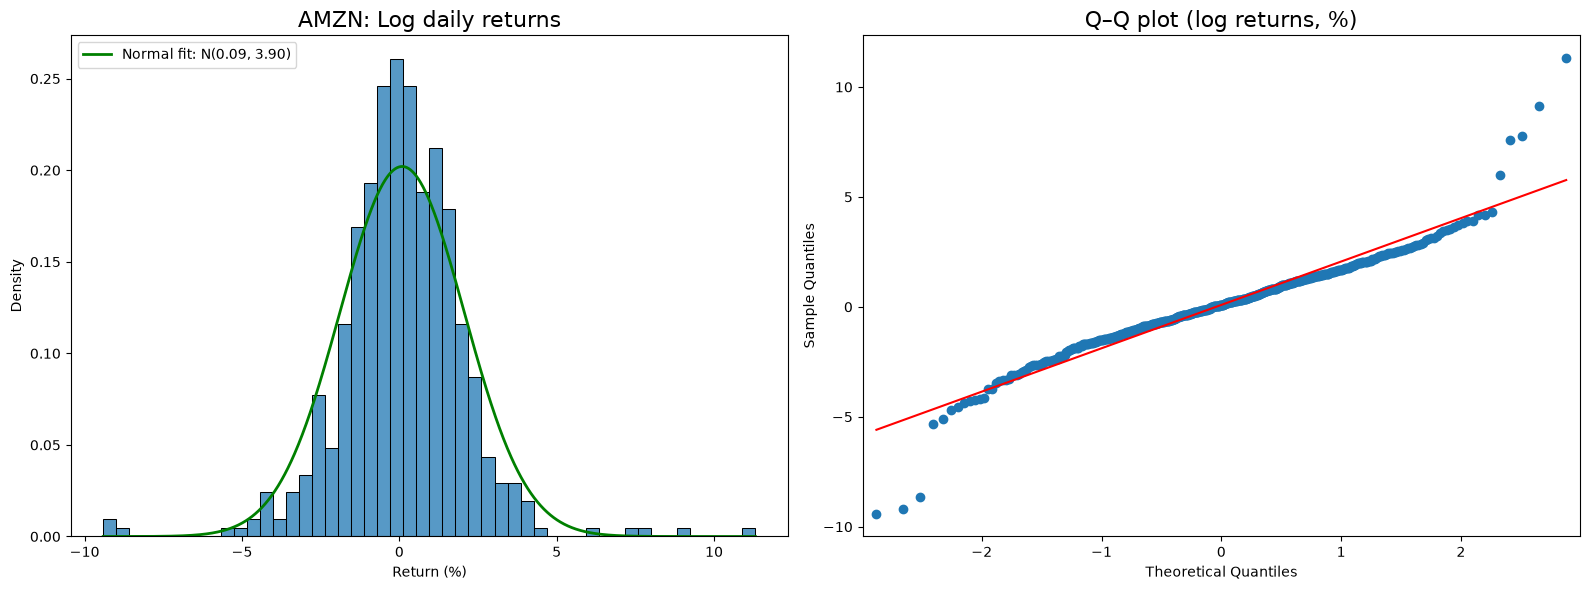

In [13]:
# Histogram + Q–Q plot: LOG returns (percent)

log_rtn_pct = df["log_rtn"] * 100

# Normal overlay parameters for log returns (percent)
r_range2 = np.linspace(log_rtn_pct.min(), log_rtn_pct.max(), 1000)
mu2 = log_rtn_pct.mean()
sigma2 = log_rtn_pct.std()
norm_pdf2 = scs.norm.pdf(r_range2, loc=mu2, scale=sigma2)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Histogram (percent)
sns.histplot(log_rtn_pct, bins=50, stat="density", ax=ax[0])
ax[0].set_title(f"{TICKER}: Log daily returns", fontsize=16)
ax[0].set_xlabel("Return (%)")
ax[0].plot(r_range2, norm_pdf2, "g", lw=2, label=f"Normal fit: N({mu2:.2f}, {sigma2**2:.2f})")
ax[0].legend(loc="upper left")

# Q–Q plot
sm.qqplot(log_rtn_pct.values, line="s", ax=ax[1])
ax[1].set_title("Q–Q plot (log returns, %)", fontsize=16)

plt.tight_layout()
plt.show()


In [14]:
# Summary statistics + normality test: LOG returns

r = df["log_rtn"].dropna()
r_pct = r * 100
jb_test = scs.jarque_bera(r.values)

print("---------- Log Returns (Daily) ----------")
print("Range of dates:", r.index.min().date(), "-", r.index.max().date())
print("Number of observations:", r.shape[0])
print(f"Mean (%): {r_pct.mean():.4f}")
print(f"Median (%): {r_pct.median():.4f}")
print(f"Min (%): {r_pct.min():.4f}")
print(f"Max (%): {r_pct.max():.4f}")
print(f"Std Dev (%): {r_pct.std():.4f}")
print(f"Skewness: {r_pct.skew():.4f}")
print(f"Excess kurtosis: {r_pct.kurtosis():.4f}")
print(f"Jarque–Bera: {jb_test[0]:.2f}  |  p-value: {jb_test[1]:.3e}")


---------- Log Returns (Daily) ----------
Range of dates: 2024-01-03 - 2025-12-30
Number of observations: 500
Mean (%): 0.0878
Median (%): 0.0708
Min (%): -9.4081
Max (%): 11.3124
Std Dev (%): 1.9747
Skewness: 0.0768
Excess kurtosis: 5.4897
Jarque–Bera: 613.17  |  p-value: 7.110e-134


## Written Responses

### Q1. Prices vs. Returns (Modeling Choice)

Figure 2 shows that AMZN's adjusted price rises overall from roughly $150 to over $230, with substantial reversals, including a sharp decline in early 2025. Its level changes across the sample, whereas daily returns fluctuate around a comparatively stable center near zero. The mean simple return is 0.1073% per day and the mean log return is 0.0878%, both small relative to their approximately 1.98% daily standard deviations. Modeling raw price levels with a constant-mean framework can therefore be misleading: trends and persistent levels can violate model assumptions and generate spurious relationships. Returns measure proportional changes and are more comparable across time and assets, making them a more suitable starting point for many statistical models. However, a plot alone does not establish stationarity or independence. Figure 2 also shows periods of larger fluctuations, particularly around April 2025, so return models may still need to accommodate changing volatility.

### Q2. Distribution Shape, Normality, and Risk

Neither simple nor log returns appears Normally distributed. In Figures 3 and 4, the histograms are more concentrated near the center than the fitted Normal curves and contain extreme observations in both tails. The Q–Q plots show lower-tail observations below the reference line and upper-tail observations above it, indicating heavier tails than a Normal distribution. Simple returns have skewness 0.2993 and excess kurtosis 5.7888; log returns have skewness 0.0768 and excess kurtosis 5.4897. Thus, log returns are closer to symmetric, but both series have substantial excess kurtosis relative to the Normal benchmark of zero. Symmetry alone is insufficient to establish Normality.

The Jarque–Bera statistics are 688.85 for simple returns (p = 2.622 × 10⁻¹⁵⁰) and 613.17 for log returns (p = 7.110 × 10⁻¹³⁴). At the 5% significance level, both tests reject the Normality null, consistent with the visual evidence. These are the notebook's asymptotic test results and should be interpreted alongside the plots rather than as proof of a specific alternative distribution. The most extreme simple daily returns are −8.9791% and +11.9770%, much larger than the daily standard deviation of 1.9797%. A Normal model calibrated only to the mean and variance can understate the likelihood of extreme outcomes, especially large losses in the left tail. This matters for loss probabilities, risk limits, and estimates of tail losses; the sample does not establish the exact probabilities of future extremes.

### Q3. Simple vs. Log Returns (Economic Interpretation)

A simple return is r = Pₜ/Pₜ₋₁ − 1, while a log return is g = ln(Pₜ/Pₜ₋₁) = ln(1 + r). For small changes, ln(1 + r) is approximately r, which explains the close resemblance of the two daily return series in Figure 2 and their similar standard deviations (1.9797% versus 1.9747%). The distinction is clearer on large-move days: the largest simple return is 11.9770%, compared with a log return of 11.3124%, while the lowest simple return is −8.9791%, compared with −9.4081% in log terms.

Simple returns describe the proportional change in investment value. Across multiple periods they compound as the product of (1 + rₜ), minus one; log returns add across time, and the corresponding cumulative simple return is exp(sum of log returns) − 1. Across assets in a single period, portfolio simple returns are weighted averages of constituent simple returns using beginning-of-period weights; portfolio log returns generally are not. The distinction becomes economically meaningful with large price movements, volatile paths, and accumulation over many periods. In this sample, the mean simple return exceeds the mean log return by about 0.0195 percentage points per day, illustrating why the two averages are not interchangeable measures of compounded performance.

### Q4. Descriptive Statistics vs. Visual Evidence

Numerical summaries quantify differences precisely, while plots show features that those summaries can conceal. For example, the means and standard deviations are similar for simple and log returns, yet excess kurtosis above 5 and the extremely small Jarque–Bera p-values reveal strong departures from Normality. Figures 3 and 4 show where those departures occur: the center and especially the tails. Figure 2 additionally preserves time order and reveals changing fluctuation sizes and large movements around April 2025, information absent from pooled summary statistics and histograms.

Relying only on a mean and standard deviation can hide asymmetry, outliers, tail behavior, and temporal changes; even skewness and kurtosis do not describe a full distribution or identify when unusual events occurred. Relying only on plots makes precise comparisons difficult, and conclusions can depend on histogram bins, axis scales, and visual judgment. Combining the table, the normality tests, and the time-series and distribution plots therefore provides a more complete and better-supported interpretation of AMZN's returns.
